[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/assignments/assignment_combined_5_6.ipynb)

# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [2]:
!pip install abtem ase

INFO: pip is looking at multiple versions of distributed to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 6.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.5 MB/s  0:00:00
  Attempting uninstall: dask╺━━━━━━━━━━━━━━━━━━━  5/10 [zarr]
    Found existing installation: dask 2025.12.0━━━━━━━━━━━━━━━  5/10 [zarr]
    Uninstalling dask-2025.12.0:m╺━━━━━━━━━━━━━━━━━━━  5/10 [zarr]
      Successfully uninstalled dask-2025.12.0━━━━━━━━━━━━━━━━━  5/10 [zarr]
  Attempting uninstall: distributedm╺━━━━━━━━━━━━━━━  6/10 [dask]
    Found existing installation: distributed 2025.12.0━━━━━━━━  6/10 [dask]
    Uninstalling distributed-2025.12.0:━━━━━━━━━━

In [1]:
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

abTEM version: 1.0.9


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

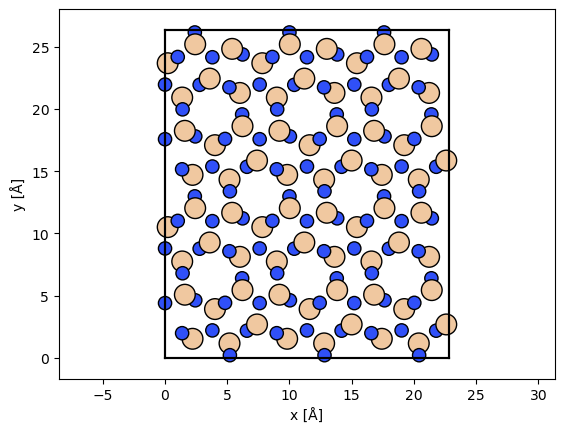

In [3]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

structure_orthogonal = abtem.orthogonalize_cell(structure)

abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy');

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

tasks:   0%|          | 0/17 [00:00<?, ?it/s]

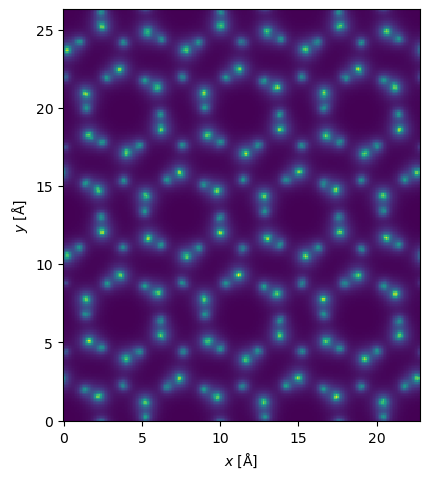

In [4]:
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},
)

potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,       
    slice_thickness=2.0,    
    parametrization='kirkland',
)

potential.project().show(cmap='viridis');


---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

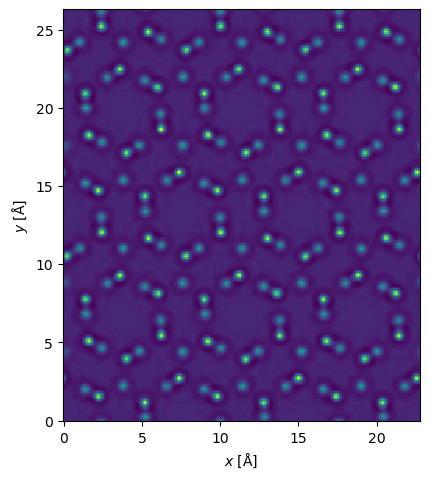

In [5]:
wave = abtem.PlaneWave(energy=300e3)

exit_waves = wave.multislice(potential)

exit_waves.intensity().mean(0).show(cmap='viridis');


---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

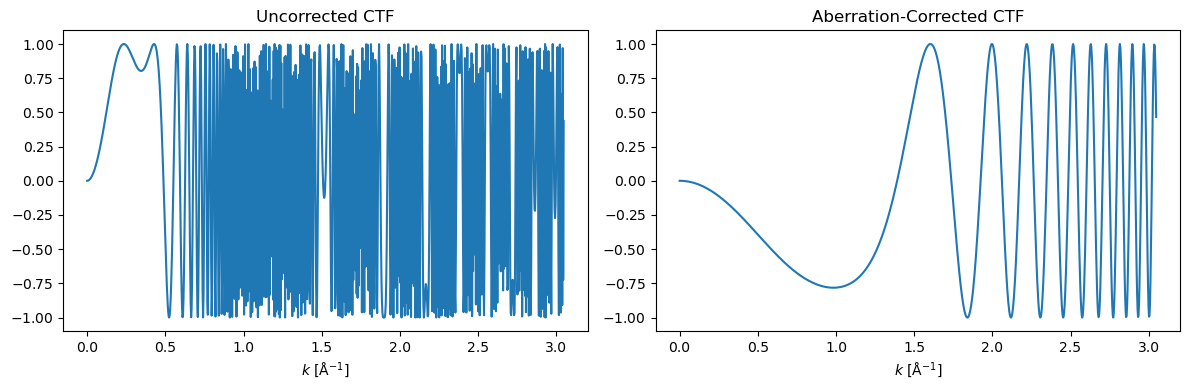

In [10]:
parameters_uncorrected = {
    'C10': -600,
    'C30': 1.3e7
}

ctf_uncorrected = abtem.CTF(
    energy=300e3,
    aberration_coefficients=parameters_uncorrected
)

parameters_corrected = {
    'C10': 30,
    'C30': -8e4
}

ctf_corrected = abtem.CTF(
    energy=300e3,
    aberration_coefficients=parameters_corrected
)

# TASK 3c: Plot both CTFs for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ctf_uncorrected.profiles(max_angle=60).show(ax=axes[0], units='mrad')
axes[0].set_title('Uncorrected CTF')

ctf_corrected.profiles(max_angle=60).show(ax=axes[1], units='mrad')
axes[1].set_title('Aberration-Corrected CTF')

plt.tight_layout()
plt.show()

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

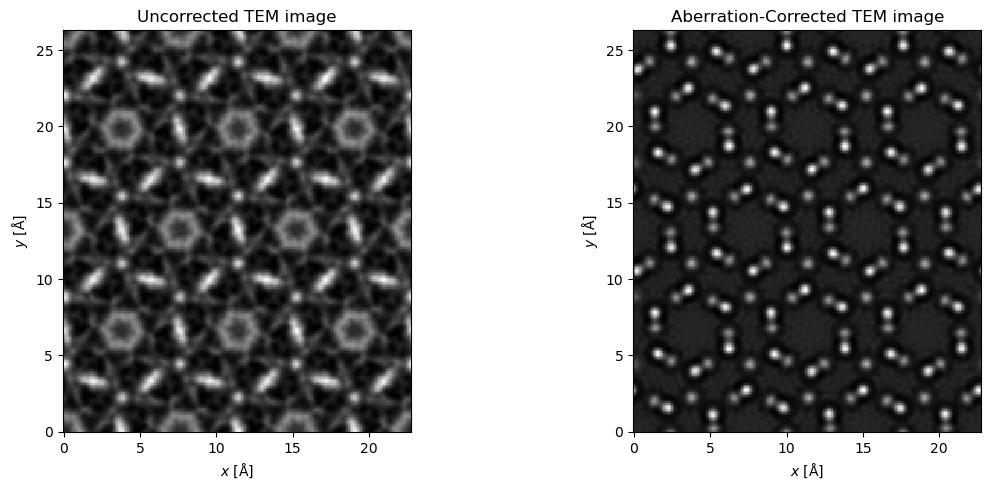

In [11]:
# TASK 3d: Apply each CTF to the exit waves
# .apply_ctf() convolves the exit wave with the CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected   = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Plot the resulting mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='gray', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')

image_corrected.intensity().mean(0).show(cmap='gray', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')

plt.tight_layout()
plt.show()


---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/33 [00:00<?, ?it/s]

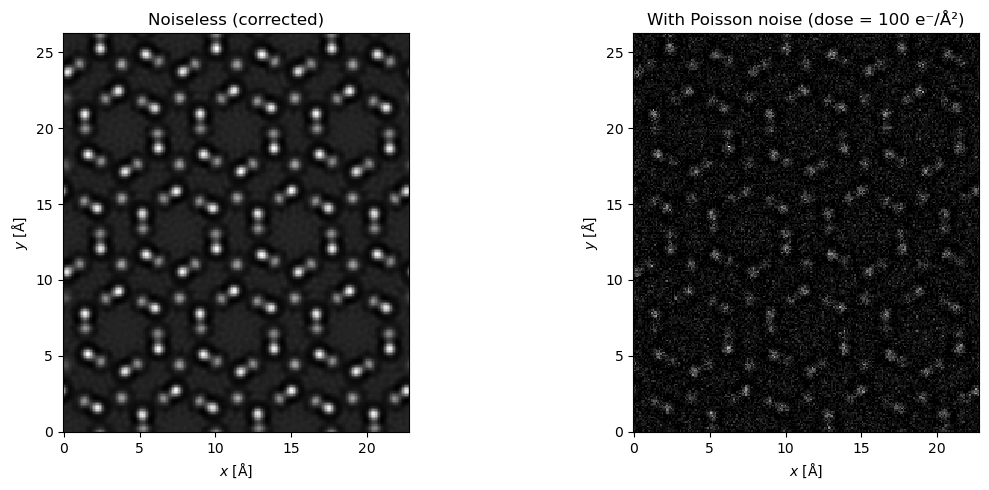

In [13]:
dose = 100  # e-/Å²

noiseless_image = image_corrected.intensity().mean(0)
noisy_image = noiseless_image.poisson_noise(dose_per_area=dose)

# TASK 4: Plot the noiseless vs noisy images side by side for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noiseless_image.show(cmap='gray', ax=axes[0])
axes[0].set_title(f'Noiseless (corrected)')

noisy_image.show(cmap='gray', ax=axes[1])
axes[1].set_title(f'With Poisson noise (dose = {dose} e⁻/Å²)')

plt.tight_layout()
plt.show()


---

# Task 6: Self-Reflection

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer? Why do we see sharper atomic columns in the aberration-corrected image?
- A: The uncorrected CTF oscillates more strongly and reaches zero crossings at lower spatial frequencies because the large positive spherical aberration and larger underfocus cause stronger phase distortion. That means some spatial frequencies are transferred with the wrong sign or not transferred at all, so fine structural information is lost or mixed. The aberration-corrected CTF stays usable over a broader spatial-frequency range and suppresses those early oscillations, so higher-frequency information from closely spaced atomic columns is preserved. As a result, the aberration-corrected image shows sharper, more localized atomic-column contrast.

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM? What is the significance of the Scherzer defocus?
- A: At exactly zero defocus in a conventional, uncorrected TEM, phase contrast is usually weak for many important spatial frequencies because the CTF is near zero over much of the low-to-intermediate frequency range. In practice, that gives poor visibility of lattice and atomic-column contrast even if the specimen is thin. The Scherzer defocus is the negative defocus value chosen to maximize the transfer of useful spatial frequencies while postponing the first CTF zero to higher frequency. It is therefore a practical operating condition that gives stronger, more interpretable high-resolution contrast in conventional TEM.

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image? What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?
- A: Adding Poisson noise lowers the signal-to-noise ratio by introducing shot noise from the finite number of detected electrons. The main effect is that weak contrast variations become harder to distinguish from random intensity fluctuations, so atomic columns look less clean and fine details become less reliable to interpret. In a real HRTEM experiment, image quality can also be degraded by sample drift, scan or stage instability, specimen tilt away from the zone axis, thickness variations, inelastic scattering, partial temporal and spatial coherence of the source, defocus spread, astigmatism and higher-order aberrations, detector noise, contamination, and beam-induced damage.

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?
- A: For a 5 nm thick specimen, the electron wave is modified repeatedly as it propagates through successive slices of projected potential, so multiple scattering and phase accumulation are important. A single projected-potential or kinematic treatment assumes the specimen is effectively very thin and that the wave interacts only once with the whole crystal, which is not accurate here. The multislice method is necessary because it alternates transmission through each slice with free-space propagation between slices, allowing the simulation to capture dynamical scattering and the thickness-dependent evolution of the exit wave.